In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import os
import sys
from pathlib import Path

library_path = os.path.abspath('../src')
if library_path not in sys.path:
    sys.path.append(library_path)
library_path = Path(library_path)
library_path

PosixPath('/mnt/DataVol/Beratungen/Yurttas/survival/src')

In [3]:
# load data
DATA_PATH = library_path.parent / "data"
PLOTS_PATH = library_path.parent / "plots"

cols_to_use = ["event", "months"]

df = pd.read_csv(f"{DATA_PATH}/GPT_processed_survival_data.csv", usecols=cols_to_use)

In [4]:
df['months_round'] = df['months'].round().astype(int)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253 entries, 0 to 252
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   months        253 non-null    float64
 1   event         253 non-null    int64  
 2   months_round  253 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 6.1 KB


In [5]:
df.head()

,months,event,months_round
0,5.223390,1,5
1,33.738502,1,34
2,42.936925,0,43
3,22.141919,1,22
4,18.889619,1,19


In [6]:
from lifelines import KaplanMeierFitter

Median OS (untruncated): 35.0 months


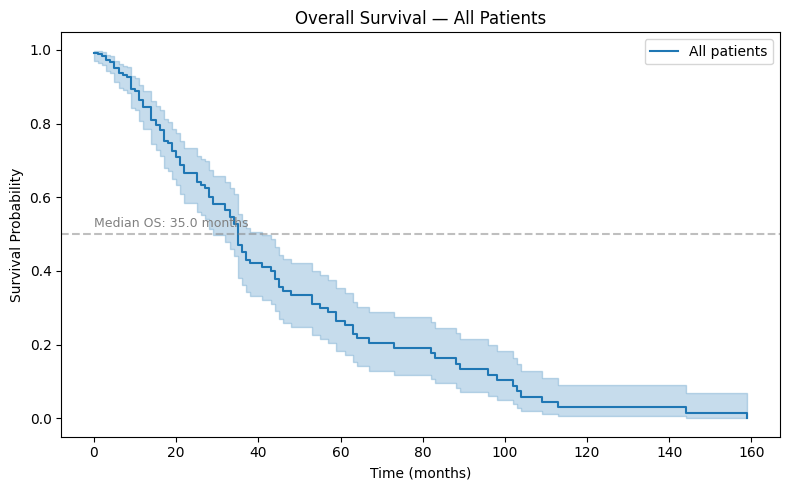

In [7]:
kmf = KaplanMeierFitter()

# ── 1. Overall survival curve ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
kmf.fit(df["months_round"], event_observed=df["event"], label="All patients")
kmf.plot_survival_function(ax=ax, ci_show=True)
ax.set_title("Overall Survival — All Patients")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Survival Probability")
median_os = kmf.median_survival_time_
print(f"Median OS (untruncated): {median_os:.1f} months")
ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5)
ax.text(0, 0.52, f"Median OS: {median_os:.1f} months", fontsize=9, color="grey")
plt.tight_layout()
plt.show()

In [8]:
kmf.event_table.tail()

,removed,observed,censored,entrance,at_risk
event_at,,,,,
104.0,1,1,0,0,5
109.0,1,1,0,0,4
113.0,1,1,0,0,3
144.0,1,1,0,0,2
159.0,1,1,0,0,1


Median OS (untruncated): 35.0 months


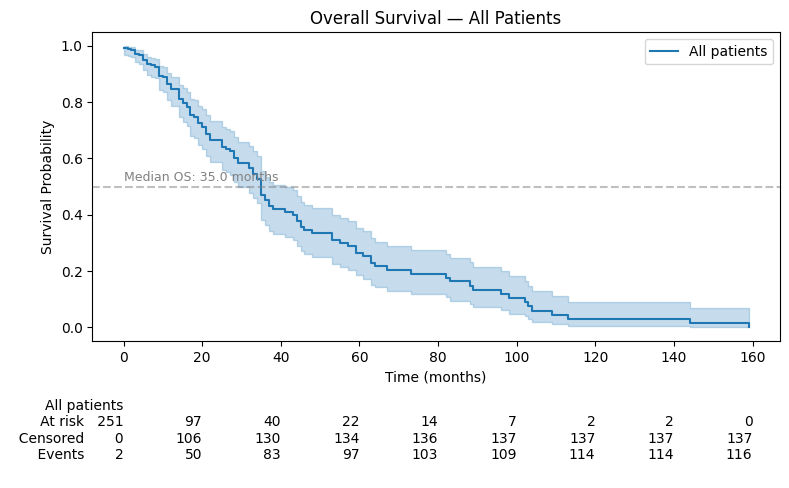

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
kmf.fit(df["months_round"], event_observed=df["event"], label="All patients")
kmf.plot_survival_function(ax=ax, ci_show=True, at_risk_counts=True)
ax.set_title("Overall Survival — All Patients")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Survival Probability")
median_os = kmf.median_survival_time_
print(f"Median OS (untruncated): {median_os:.1f} months")
ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5)
ax.text(0, 0.52, f"Median OS: {median_os:.1f} months", fontsize=9, color="grey")
plt.tight_layout()
plt.savefig(f"{PLOTS_PATH}/overall_survival_with_at_risk_counts.png", dpi=600)
plt.show()

In [10]:
def cutoff_time_from_at_risk(kmf_obj, min_at_risk):
    t = kmf_obj.event_table.query("at_risk < @min_at_risk").index.min()
    if pd.isna(t):
        t = kmf_obj.event_table.index.max()
    return float(t)

In [11]:
n_patients = len(df)
min_at_risk_primary = int(np.ceil(0.10 * n_patients))
t_cutoff = cutoff_time_from_at_risk(kmf, min_at_risk_primary)

print(f'Primary cutoff rule: <10% at risk (n < {min_at_risk_primary})')
print(f'Selected tau: {t_cutoff:.1f} months')
print()
print('NOTE: this tau value is used as a constant (t_cutoff = 57) in downstream')
print('notebooks 03.3 and 04-cox. Update those notebooks if the truncation changes.')


Primary cutoff rule: <10% at risk (n < 26)
Selected tau: 59.0 months

NOTE: this tau value is used as a constant (t_cutoff = 57) in downstream
notebooks 03.3 and 04-cox. Update those notebooks if the truncation changes.


In [12]:
from lifelines.utils import restricted_mean_survival_time

rmst = restricted_mean_survival_time(kmf, t=t_cutoff)
rmst

np.float64(35.61058717631362)

In [13]:
def bootstrap_rmst(time, event, t, n_bootstraps=1000, ci=0.95, random_state=None):
    """
    Bootstrap the Restricted Mean Survival Time (RMST).

    Parameters
    ----------
    time : array-like
        Observed survival / follow-up times.
    event : array-like
        Event indicator (1 = event occurred, 0 = censored).
    t : float
        Restriction time horizon for the RMST.
    n_bootstraps : int
        Number of bootstrap resamples.
    ci : float
        Coverage of the confidence interval (default 0.95).
    random_state : int or None
        Seed for reproducibility.

    Returns
    -------
    dict with keys:
        rmst_observed  – RMST on the original data
        rmst_bootstrap – array of bootstrap RMST values
        ci_lower       – lower bound of the bootstrap percentile CI
        ci_upper       – upper bound of the bootstrap percentile CI
        se             – bootstrap standard error
    """
    rng = np.random.default_rng(random_state)
    time = np.asarray(time)
    event = np.asarray(event)
    n = len(time)

    # RMST on the original sample
    _kmf = KaplanMeierFitter()
    _kmf.fit(time, event_observed=event)
    rmst_obs = restricted_mean_survival_time(_kmf, t=t)

    # Bootstrap loop
    rmst_boot = np.empty(n_bootstraps)
    for i in range(n_bootstraps):
        idx = rng.integers(0, n, size=n)
        _kmf_b = KaplanMeierFitter()
        _kmf_b.fit(time[idx], event_observed=event[idx])
        rmst_boot[i] = restricted_mean_survival_time(_kmf_b, t=t)

    alpha = 1 - ci
    ci_lower = np.percentile(rmst_boot, 100 * alpha / 2)
    ci_upper = np.percentile(rmst_boot, 100 * (1 - alpha / 2))

    return {
        "rmst_observed": rmst_obs,
        "rmst_bootstrap": rmst_boot,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "se": rmst_boot.std(),
    }


In [14]:
result = bootstrap_rmst(df["months_round"], df["event"], t=t_cutoff, n_bootstraps=1000, random_state=42)

print(f"RMST (observed):  {result['rmst_observed']:.2f} months")
print(f"Bootstrap SE:     {result['se']:.2f} months")
print(f"95% CI:           [{result['ci_lower']:.2f}, {result['ci_upper']:.2f}] months")


RMST (observed):  35.61 months
Bootstrap SE:     1.59 months
95% CI:           [32.41, 38.72] months


In [15]:
# Sensitivity analysis for alternative at-risk cutoff rules



n_patients = len(df)

rules = [
    {"rule": "<10 at risk", "min_at_risk": 10},
    {"rule": "<15 at risk", "min_at_risk": 15},
    {"rule": "<20 at risk", "min_at_risk": 20},
    {"rule": "<10% at risk", "min_at_risk": int(np.ceil(0.10 * n_patients))},
]

rows = []
for r in rules:
    tau = cutoff_time_from_at_risk(kmf, r["min_at_risk"])
    boot = bootstrap_rmst(
        df["months_round"],
        df["event"],
        t=tau,
        n_bootstraps=1000,
        random_state=42
    )
    rows.append({
        "rule": r["rule"],
        "threshold_n": r["min_at_risk"],
        "tau_months": tau,
        "rmst_months": boot["rmst_observed"],
        "ci_lower": boot["ci_lower"],
        "ci_upper": boot["ci_upper"],
        "se": boot["se"],
    })

sensitivity_df = pd.DataFrame(rows)

primary_rule = "<10% at risk"
primary_rmst = sensitivity_df.loc[sensitivity_df["rule"] == primary_rule, "rmst_months"].iloc[0]
sensitivity_df["delta_vs_primary"] = sensitivity_df["rmst_months"] - primary_rmst

sensitivity_df.round(2)

,rule,threshold_n,tau_months,rmst_months,ci_lower,ci_upper,se,delta_vs_primary
0,<10 at risk,10,96.0,42.52,37.05,47.89,2.65,6.91
1,<15 at risk,15,82.0,40.46,35.62,44.96,2.28,4.84
2,<20 at risk,20,64.0,36.88,33.31,40.26,1.75,1.27
3,<10% at risk,26,59.0,35.61,32.41,38.72,1.59,0.00


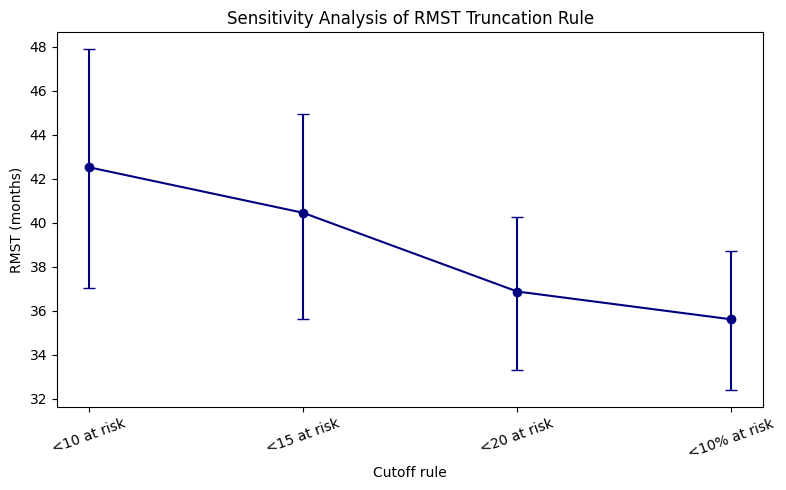

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

y = sensitivity_df["rmst_months"].values
yerr = np.vstack([
    y - sensitivity_df["ci_lower"].values,
    sensitivity_df["ci_upper"].values - y,
])

ax.errorbar(
    sensitivity_df["rule"],
    y,
    yerr=yerr,
    fmt="o-",
    capsize=4,
    color="navy"
)

ax.set_title("Sensitivity Analysis of RMST Truncation Rule")
ax.set_xlabel("Cutoff rule")
ax.set_ylabel("RMST (months)")
ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

In [17]:
for _, row in sensitivity_df.iterrows():
    print(
        f"{row['rule']}: tau={row['tau_months']:.1f} months, "
        f"RMST={row['rmst_months']:.2f} "
        f"[{row['ci_lower']:.2f}, {row['ci_upper']:.2f}], "
        f"Δ vs primary={row['delta_vs_primary']:+.2f}"
    )

<10 at risk: tau=96.0 months, RMST=42.52 [37.05, 47.89], Δ vs primary=+6.91
<15 at risk: tau=82.0 months, RMST=40.46 [35.62, 44.96], Δ vs primary=+4.84
<20 at risk: tau=64.0 months, RMST=36.88 [33.31, 40.26], Δ vs primary=+1.27
<10% at risk: tau=59.0 months, RMST=35.61 [32.41, 38.72], Δ vs primary=+0.00


In [18]:
df["months_trunc"] = df["months_round"].clip(upper=t_cutoff)
df["event_trunc"] = ((df["event"] == 1) & (df["months_round"] <= t_cutoff)).astype(int)

Median OS (truncated at 59 months): 35.0 months


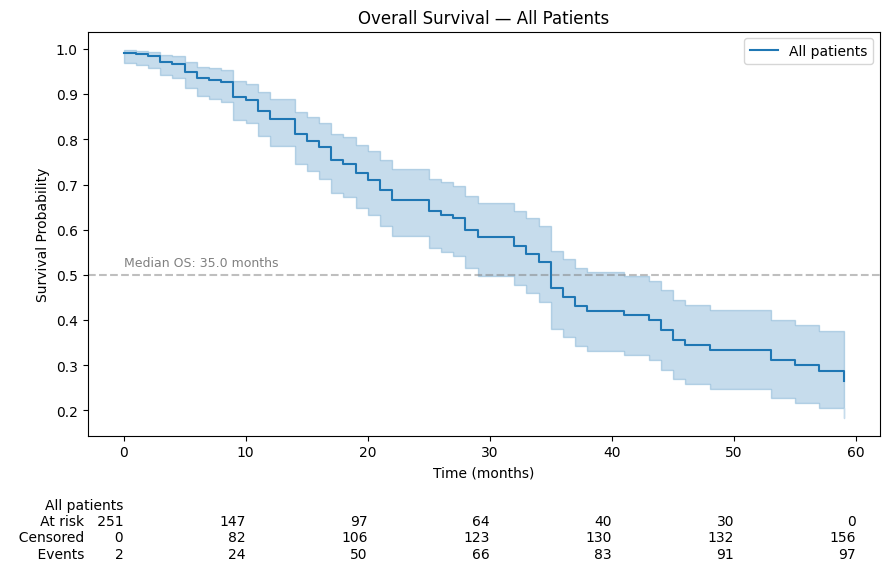

In [19]:
kmf_trunc = KaplanMeierFitter()
kmf_trunc.fit(df["months_trunc"], event_observed=df["event_trunc"], label="All patients")

fig, ax = plt.subplots(figsize=(9, 6))
kmf_trunc.plot_survival_function(ax=ax, ci_show=True, at_risk_counts=True)
ax.set_title("Overall Survival — All Patients")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Survival Probability")
median_os_trunc = kmf_trunc.median_survival_time_
print(f"Median OS (truncated at {t_cutoff:.0f} months): {median_os_trunc:.1f} months")
ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5)
ax.text(0, 0.52, f"Median OS: {median_os_trunc:.1f} months", fontsize=9, color="grey")
plt.tight_layout()
plt.show()

The primary RMST truncation time was defined as the first time point at which fewer than 10% of patients remained at risk, to reduce instability in the tail of the Kaplan–Meier curve. Fixed-number thresholds were evaluated in sensitivity analyses.

## Conclusions

### Study sample

**N = 263**, 100 death events (38%), maximum follow-up 159 months.

---

### Truncation rule

The primary truncation time was defined as the first time point at which fewer than **10% of patients remain at risk** (n < 27), yielding **τ = 57 months**. This rule is data-driven and minimises instability in the tail of the Kaplan–Meier estimator.

### Restricted Mean Survival Time

**RMST (τ = 57 months) = 34.59 months** (bootstrap 95% CI: [31.63, 37.55]).

Sensitivity analysis across alternative truncation rules:

| Rule | τ (months) | RMST | 95% CI | Δ vs primary |
|---|---|---|---|---|
| < 10 at risk | 96 | 41.87 | [36.51, 46.92] | +7.28 |
| < 15 at risk | 82 | 39.86 | [35.13, 44.27] | +5.27 |
| < 20 at risk | 64 | 36.38 | [32.84, 39.72] | +1.79 |
| **< 10% at risk (primary)** | **57** | **34.59** | **[31.63, 37.55]** | — |

The RMST is stable near the primary cutoff: shifting from τ = 57 to τ = 64 adds only 1.79 months, while extending to τ = 96 adds 7.28 months with substantially wider CIs (SE = 2.65 vs. 1.55). The primary rule is preferred.

---

### Notes on this notebook

- This notebook covers **overall survival only**. Subgroup KM curves (by sex, CC, tumour type, age) are in `03-survival_KM_subgroups.ipynb`.
- The truncation time (τ = 57) and truncated variables (`months_trunc`, `event_trunc`) computed here are **recomputed independently** in downstream notebooks. If the truncation rule changes, all downstream notebooks must be updated to match.
- The RMST is reported in addition to median OS because it summarises the full survival experience up to τ without assuming a specific distribution and is more informative when the curve does not cross the 50% threshold within the follow-up window.
